<a href="https://colab.research.google.com/github/Sharath0Kumar/aiml_lab/blob/main/AML_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df["target"].value_counts()

,count
target,
1,526
0,499


# Preprocessing

In [ ]:
x = df.drop("target", axis = 1)
y = df["target"]

In [ ]:
print("X shape : " , x.shape)
print("Y shape : " , y.shape)

X shape :  (1025, 13)
Y shape :  (1025,)


In [ ]:
print(y.value_counts())

print(y.value_counts(normalize=True) *100)

target
1    526
0    499
Name: count, dtype: int64
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42, stratify = y)

In [ ]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (820, 13)
x_test : (205, 13)
y_train: (820,)
y_test : (205,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state =42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_train_predict = dt_model.predict(x_train)

y_test_predict = dt_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 0.9853658536585366


In [ ]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 9
Number of Leaves: 49


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



# Confusion Matrix

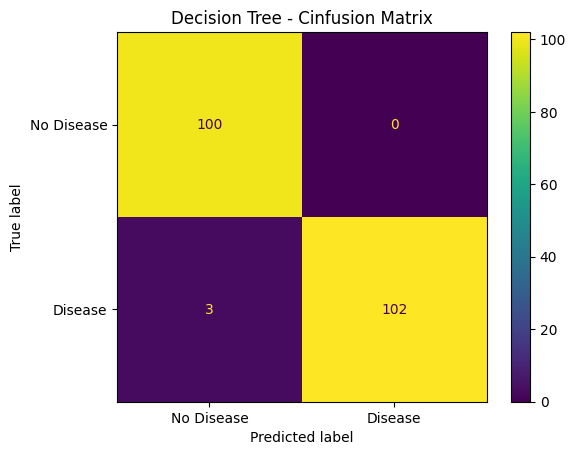

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_predict)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Disease" , "Disease"])
disp.plot()
plt.title("Decision Tree - Cinfusion Matrix")
plt.show()

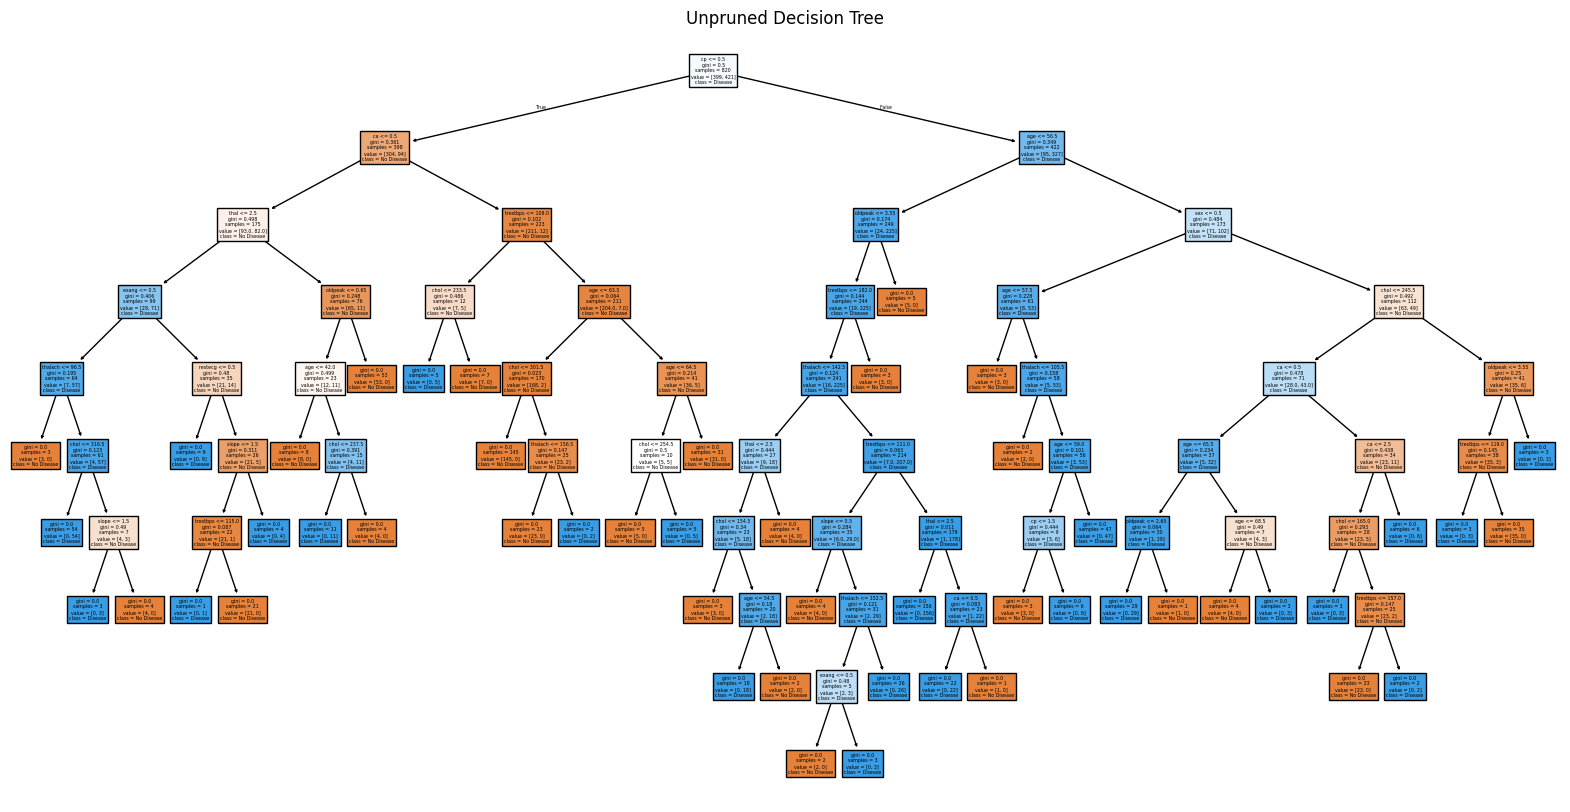

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize = (20,10))

plot_tree(dt_model , feature_names= x.columns, class_names= ["No Disease" , "Disease"], filled =True)

plt.title("Unpruned Decision Tree")
plt.show()

# Overfitting

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(1,16)
train_accuracy = []
test_accuracy = []

for depth in depths:
    dt_model = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    dt_model.fit(x_train, y_train)

    y_train_pred = dt_model.predict(x_train)
    y_test_pred = dt_model.predict(x_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)

In [ ]:
for depth, train_acc, test_acc in zip(
    depths,
    train_accuracy,
    test_accuracy
):
    print(
        f"Depth {depth:2d} | "
        f"Training: {train_acc:.4f} | "
        f"Testing: {test_acc:.4f}"
    )

Depth  1 | Training: 0.7695 | Testing: 0.7220
Depth  2 | Training: 0.7695 | Testing: 0.7220
Depth  3 | Training: 0.8451 | Testing: 0.8537
Depth  4 | Training: 0.8854 | Testing: 0.8390
Depth  5 | Training: 0.9293 | Testing: 0.8732
Depth  6 | Training: 0.9659 | Testing: 0.9220
Depth  7 | Training: 0.9915 | Testing: 0.9512
Depth  8 | Training: 0.9976 | Testing: 0.9756
Depth  9 | Training: 1.0000 | Testing: 0.9854
Depth 10 | Training: 1.0000 | Testing: 0.9854
Depth 11 | Training: 1.0000 | Testing: 0.9854
Depth 12 | Training: 1.0000 | Testing: 0.9854
Depth 13 | Training: 1.0000 | Testing: 0.9854
Depth 14 | Training: 1.0000 | Testing: 0.9854
Depth 15 | Training: 1.0000 | Testing: 0.9854


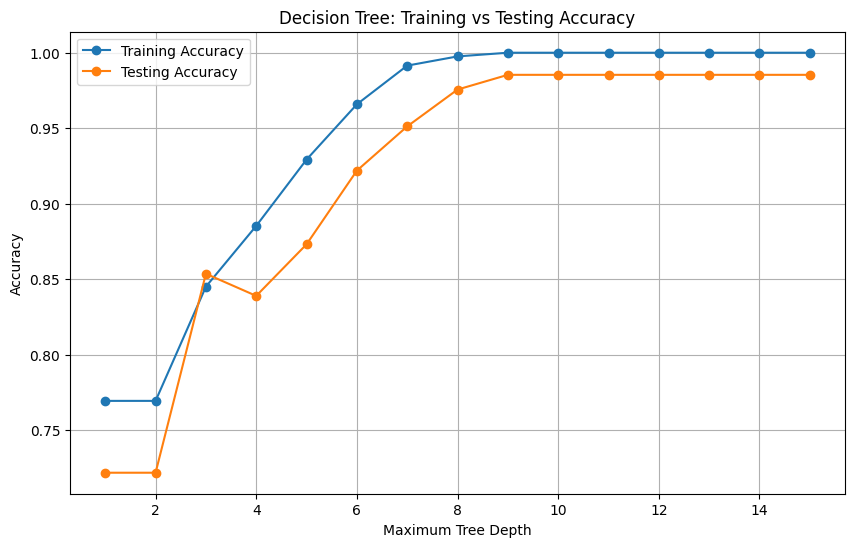

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracy,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depths,
    test_accuracy,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Testing Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
gaps = [
    train_acc - test_acc
    for train_acc, test_acc
    in zip(train_accuracy, test_accuracy)
]

for depth, gap in zip(depths, gaps):
    print(f"Depth {depth:2d} | Generalization Gap: {gap:.4f}")

Depth  1 | Generalization Gap: 0.0476
Depth  2 | Generalization Gap: 0.0476
Depth  3 | Generalization Gap: -0.0085
Depth  4 | Generalization Gap: 0.0463
Depth  5 | Generalization Gap: 0.0561
Depth  6 | Generalization Gap: 0.0439
Depth  7 | Generalization Gap: 0.0402
Depth  8 | Generalization Gap: 0.0220
Depth  9 | Generalization Gap: 0.0146
Depth 10 | Generalization Gap: 0.0146
Depth 11 | Generalization Gap: 0.0146
Depth 12 | Generalization Gap: 0.0146
Depth 13 | Generalization Gap: 0.0146
Depth 14 | Generalization Gap: 0.0146
Depth 15 | Generalization Gap: 0.0146


In [ ]:
df.duplicated().sum()

np.int64(723)

# Decision Tree Pruning

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

path = dt.cost_complexity_pruning_path(x_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of possible alpha values:", len(ccp_alphas))
print("CCP Alpha values:")
print(ccp_alphas)

Number of possible alpha values: 37
CCP Alpha values:
[0.         0.0012127  0.00228167 0.00232816 0.00235772 0.00241033
 0.00346254 0.00389537 0.0040947  0.00418118 0.00421873 0.00439024
 0.0044878  0.00476298 0.00493517 0.00512195 0.00528471 0.00552962
 0.00559328 0.0058094  0.00608944 0.00624628 0.00629935 0.00699894
 0.00752175 0.00813179 0.00894821 0.0101616  0.0106379  0.01266401
 0.01328398 0.01337269 0.01792183 0.02455055 0.03436205 0.04114047
 0.14497488]


In [ ]:
from sklearn.model_selection import GridSearchCV

dt_pruning = DecisionTreeClassifier(random_state=42)

param_grid = {
    "ccp_alpha": ccp_alphas
}

grid_search = GridSearchCV(
    estimator=dt_pruning,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'ccp_alpha': array([0.        , 0.0012127 , 0.00228167, 0.00232816, 0.00235772,
       0.00241033, 0.00346254, 0.00389537, 0.0040947 , 0.00418118,
       0.00421873, 0.00439024, 0.0044878 , 0.00476298, 0.00493517,
       0.00512195, 0.00528471, 0.00552962, 0.00559328, 0.0058094 ,
       0.00608944, 0.00624628, 0.00629935, 0.00699894, 0.00752175,
       0.00813179, 0.00894821, 0.0101616 , 0.0106379 , 0.01266401,
       0.01328398, 0.01337269, 0.01792183, 0.02455055, 0.03436205,
       0.04114047, 0.14497488])},
             scoring='accuracy')

In [ ]:
best_alpha = grid_search.best_params_["ccp_alpha"]

print("Best ccp_alpha:", best_alpha)
print("Best CV Accuracy:", grid_search.best_score_)

Best ccp_alpha: 0.0
Best CV Accuracy: 0.9865853658536585


In [ ]:
pruned_tree = grid_search.best_estimator_

print("Pruned Tree Depth:", pruned_tree.get_depth())
print("Pruned Number of Leaves:", pruned_tree.get_n_leaves())

Pruned Tree Depth: 9
Pruned Number of Leaves: 49


In [ ]:
from sklearn.metrics import accuracy_score

y_test_pruned = pruned_tree.predict(x_test)

pruned_test_accuracy = accuracy_score(
    y_test,
    y_test_pruned
)

print("Pruned Tree Test Accuracy:", pruned_test_accuracy)

Pruned Tree Test Accuracy: 0.9853658536585366


In [ ]:
y_train_pruned = pruned_tree.predict(x_train)

pruned_train_accuracy = accuracy_score(
    y_train,
    y_train_pruned
)

print("Pruned Tree Training Accuracy:", pruned_train_accuracy)

Pruned Tree Training Accuracy: 1.0


In [ ]:
print("----- Original Tree -----")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Depth            :", dt_model.get_depth())
print("Leaves           :", dt_model.get_n_leaves())

print("\n----- Pruned Tree -----")
print("Training Accuracy:", pruned_train_accuracy)
print("Testing Accuracy :", pruned_test_accuracy)
print("Depth            :", pruned_tree.get_depth())
print("Leaves           :", pruned_tree.get_n_leaves())

----- Original Tree -----
Training Accuracy: [0.7695121951219512, 0.7695121951219512, 0.8451219512195122, 0.8853658536585366, 0.9292682926829269, 0.9658536585365853, 0.9914634146341463, 0.9975609756097561, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Testing Accuracy : [0.7219512195121951, 0.7219512195121951, 0.8536585365853658, 0.8390243902439024, 0.8731707317073171, 0.9219512195121952, 0.9512195121951219, 0.975609756097561, 0.9853658536585366, 0.9853658536585366, 0.9853658536585366, 0.9853658536585366, 0.9853658536585366, 0.9853658536585366, 0.9853658536585366]
Depth            : 9
Leaves           : 49

----- Pruned Tree -----
Training Accuracy: 1.0
Testing Accuracy : 0.9853658536585366
Depth            : 9
Leaves           : 49


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
original_train_pred = dt_model.predict(x_train)
original_test_pred = dt_model.predict(x_test)

original_train_accuracy = accuracy_score(
    y_train,
    original_train_pred
)

original_test_accuracy = accuracy_score(
    y_test,
    original_test_pred
)

print("Original Training Accuracy:", original_train_accuracy)
print("Original Testing Accuracy :", original_test_accuracy)

Original Training Accuracy: 1.0
Original Testing Accuracy : 0.9853658536585366


In [ ]:
print("----- Original Tree -----")
print("Training Accuracy:", original_train_accuracy)
print("Testing Accuracy :", original_test_accuracy)
print("Depth            :", dt_model.get_depth())
print("Leaves           :", dt_model.get_n_leaves())

print("\n----- Pruned Tree -----")
print("Training Accuracy:", pruned_train_accuracy)
print("Testing Accuracy :", pruned_test_accuracy)
print("Depth            :", pruned_tree.get_depth())
print("Leaves           :", pruned_tree.get_n_leaves())

----- Original Tree -----
Training Accuracy: 1.0
Testing Accuracy : 0.9853658536585366
Depth            : 9
Leaves           : 49

----- Pruned Tree -----
Training Accuracy: 1.0
Testing Accuracy : 0.9853658536585366
Depth            : 9
Leaves           : 49


**Logistic** **Regression**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, penalty=None, random_state=42)

In [ ]:
y_train_logistic = logistic_model.predict(X_train_scaled)
y_test_logistic = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

logistic_train_accuracy = accuracy_score(
    y_train,
    y_train_logistic
)

logistic_test_accuracy = accuracy_score(
    y_test,
    y_test_logistic
)

print("Logistic Regression Training Accuracy:",
      logistic_train_accuracy)

print("Logistic Regression Testing Accuracy:",
      logistic_test_accuracy)

Logistic Regression Training Accuracy: 0.8463414634146341
Logistic Regression Testing Accuracy: 0.8097560975609757


**Ridge Logistic Regression**

In [ ]:
ridge_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [ ]:
y_train_ridge = ridge_model.predict(X_train_scaled)
y_test_ridge = ridge_model.predict(X_test_scaled)

ridge_train_accuracy = accuracy_score(
    y_train,
    y_train_ridge
)

ridge_test_accuracy = accuracy_score(
    y_test,
    y_test_ridge
)

print("Ridge Training Accuracy:", ridge_train_accuracy)
print("Ridge Testing Accuracy :", ridge_test_accuracy)

Ridge Training Accuracy: 0.8463414634146341
Ridge Testing Accuracy : 0.8097560975609757


**Lasso Logistic Regression**

In [ ]:
lasso_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lasso_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:
y_train_lasso = lasso_model.predict(X_train_scaled)
y_test_lasso = lasso_model.predict(X_test_scaled)

lasso_train_accuracy = accuracy_score(
    y_train,
    y_train_lasso
)

lasso_test_accuracy = accuracy_score(
    y_test,
    y_test_lasso
)

print("Lasso Training Accuracy:", lasso_train_accuracy)
print("Lasso Testing Accuracy :", lasso_test_accuracy)

Lasso Training Accuracy: 0.8463414634146341
Lasso Testing Accuracy : 0.8097560975609757


In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": x_train.columns,
    "Logistic": logistic_model.coef_[0],
    "Ridge": ridge_model.coef_[0],
    "Lasso": lasso_model.coef_[0]
})

print(coefficients)

     Feature  Logistic     Ridge     Lasso
0        age -0.114370 -0.115423 -0.112078
1        sex -0.801204 -0.782266 -0.772790
2         cp  0.882811  0.867184  0.859258
3   trestbps -0.371389 -0.363109 -0.356356
4       chol -0.284919 -0.276032 -0.266423
5        fbs -0.016470 -0.016040 -0.004956
6    restecg  0.165741  0.162794  0.154707
7    thalach  0.419274  0.413502  0.405124
8      exang -0.521753 -0.516814 -0.511756
9    oldpeak -0.622510 -0.611777 -0.606018
10     slope  0.371875  0.366415  0.361161
11        ca -0.759816 -0.745727 -0.738992
12      thal -0.504962 -0.498948 -0.490258


In [ ]:
print("Lasso coefficients:")
print(lasso_model.coef_[0])

Lasso coefficients:
[-0.11207835 -0.77279039  0.8592579  -0.3563565  -0.26642279 -0.00495593
  0.15470731  0.40512411 -0.51175606 -0.60601821  0.36116093 -0.73899208
 -0.49025779]


In [ ]:
print(
    "Number of zero Lasso coefficients:",
    sum(lasso_model.coef_[0] == 0)
)

Number of zero Lasso coefficients: 0


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge Logistic Regression",
        "Lasso Logistic Regression"
    ],
    "Training Accuracy": [
        logistic_train_accuracy,
        ridge_train_accuracy,
        lasso_train_accuracy
    ],
    "Testing Accuracy": [
        logistic_test_accuracy,
        ridge_test_accuracy,
        lasso_test_accuracy
    ]
})

print(comparison)

                       Model  Training Accuracy  Testing Accuracy
0        Logistic Regression           0.846341          0.809756
1  Ridge Logistic Regression           0.846341          0.809756
2  Lasso Logistic Regression           0.846341          0.809756


**Test Ridge with different C values**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_results = []

for C in C_values:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    ridge_results.append(
        [C, train_acc, test_acc]
    )

print("C\tTraining\tTesting")

for result in ridge_results:
    print(
        f"{result[0]}\t"
        f"{result[1]:.4f}\t\t"
        f"{result[2]:.4f}"
    )

C	Training	Testing
0.001	0.8317		0.8098
0.01	0.8341		0.8146
0.1	0.8463		0.8098
1	0.8463		0.8098
10	0.8463		0.8098
100	0.8463		0.8098


**for Lasso**

In [ ]:
lasso_results = []

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    lasso_results.append(
        [C, train_acc, test_acc]
    )

print("C\tTraining\tTesting")

for result in lasso_results:
    print(
        f"{result[0]}\t"
        f"{result[1]:.4f}\t\t"
        f"{result[2]:.4f}"
    )

C	Training	Testing
0.001	0.4866		0.4878
0.01	0.8171		0.7707
0.1	0.8427		0.8049
1	0.8463		0.8098
10	0.8463		0.8098
100	0.8463		0.8098


**Plot Ridge performance**

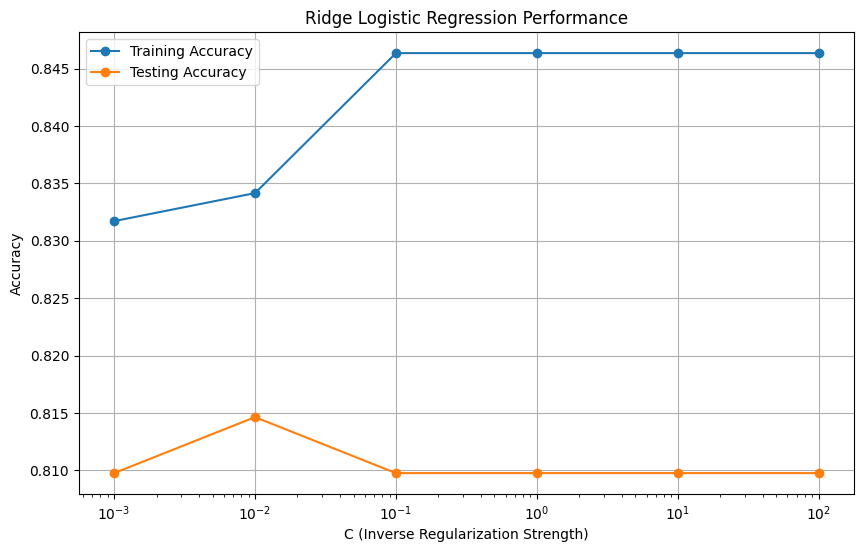

In [ ]:
import matplotlib.pyplot as plt

ridge_C = [r[0] for r in ridge_results]
ridge_train = [r[1] for r in ridge_results]
ridge_test = [r[2] for r in ridge_results]

plt.figure(figsize=(10, 6))

plt.semilogx(
    ridge_C,
    ridge_train,
    marker='o',
    label='Training Accuracy'
)

plt.semilogx(
    ridge_C,
    ridge_test,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Ridge Logistic Regression Performance")
plt.legend()
plt.grid(True)

plt.show()

**Plot Lasso performance**

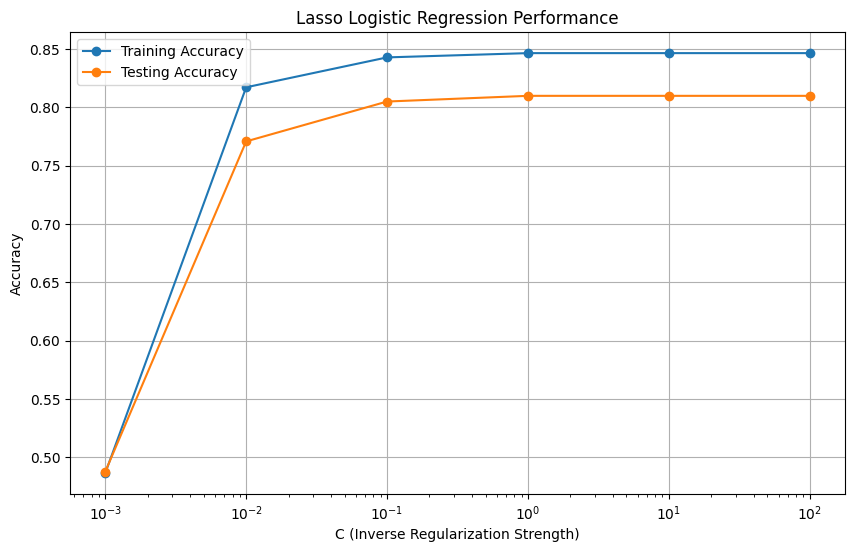

In [ ]:
lasso_C = [r[0] for r in lasso_results]
lasso_train = [r[1] for r in lasso_results]
lasso_test = [r[2] for r in lasso_results]

plt.figure(figsize=(10, 6))

plt.semilogx(
    lasso_C,
    lasso_train,
    marker='o',
    label='Training Accuracy'
)

plt.semilogx(
    lasso_C,
    lasso_test,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Lasso Logistic Regression Performance")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_ridge = max(ridge_results, key=lambda x: x[2])
best_lasso = max(lasso_results, key=lambda x: x[2])

print("Best Ridge:")
print("C:", best_ridge[0])
print("Training Accuracy:", best_ridge[1])
print("Testing Accuracy:", best_ridge[2])

print("\nBest Lasso:")
print("C:", best_lasso[0])
print("Training Accuracy:", best_lasso[1])
print("Testing Accuracy:", best_lasso[2])

Best Ridge:
C: 0.01
Training Accuracy: 0.8341463414634146
Testing Accuracy: 0.8146341463414634

Best Lasso:
C: 1
Training Accuracy: 0.8463414634146341
Testing Accuracy: 0.8097560975609757


In [ ]:
lasso_coefficients = []

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    zero_count = sum(model.coef_[0] == 0)

    lasso_coefficients.append([C, zero_count])

for C, zeros in lasso_coefficients:
    print(f"C = {C:<6} | Zero coefficients = {zeros}")

C = 0.001  | Zero coefficients = 13
C = 0.01   | Zero coefficients = 7
C = 0.1    | Zero coefficients = 1
C = 1      | Zero coefficients = 0
C = 10     | Zero coefficients = 0
C = 100    | Zero coefficients = 0


**Find the best Ridge C**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_grid = GridSearchCV(
    LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),
    param_grid={"C": C_values},
    cv=5,
    scoring="accuracy"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge C:", ridge_grid.best_params_["C"])
print("Best Ridge CV Accuracy:", ridge_grid.best_score_)

Best Ridge C: 1
Best Ridge CV Accuracy: 0.8439024390243903


**for Lasso**

In [ ]:
lasso_grid = GridSearchCV(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),
    param_grid={"C": C_values},
    cv=5,
    scoring="accuracy"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso C:", lasso_grid.best_params_["C"])
print("Best Lasso CV Accuracy:", lasso_grid.best_score_)

Best Lasso C: 1
Best Lasso CV Accuracy: 0.8402439024390244


In [ ]:
best_ridge_model = ridge_grid.best_estimator_
best_lasso_model = lasso_grid.best_estimator_

In [ ]:
ridge_test_pred = best_ridge_model.predict(X_test_scaled)
lasso_test_pred = best_lasso_model.predict(X_test_scaled)

ridge_final_accuracy = accuracy_score(
    y_test,
    ridge_test_pred
)

lasso_final_accuracy = accuracy_score(
    y_test,
    lasso_test_pred
)

print("Final Ridge Test Accuracy:", ridge_final_accuracy)
print("Final Lasso Test Accuracy:", lasso_final_accuracy)

Final Ridge Test Accuracy: 0.8097560975609757
Final Lasso Test Accuracy: 0.8097560975609757


In [ ]:
logistic_test_pred = logistic_model.predict(X_test_scaled)

logistic_final_accuracy = accuracy_score(
    y_test,
    logistic_test_pred
)

print("Logistic Regression Test Accuracy:",
      logistic_final_accuracy)

Logistic Regression Test Accuracy: 0.8097560975609757


In [ ]:
original_tree_test_accuracy = accuracy_score(
    y_test,
    dt_model.predict(x_test)
)

In [ ]:
pruned_tree_test_accuracy = accuracy_score(
    y_test,
    pruned_tree.predict(x_test)
)

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Pruned Decision Tree",
        "Logistic Regression",
        "Ridge Logistic Regression",
        "Lasso Logistic Regression"
    ],

    "Test Accuracy": [
        original_tree_test_accuracy,
        pruned_tree_test_accuracy,
        logistic_final_accuracy,
        ridge_final_accuracy,
        lasso_final_accuracy
    ]
})

print(final_comparison)

                       Model  Test Accuracy
0              Decision Tree       0.985366
1       Pruned Decision Tree       0.985366
2        Logistic Regression       0.809756
3  Ridge Logistic Regression       0.809756
4  Lasso Logistic Regression       0.809756


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt_model.predict(x_test),
    "Pruned Decision Tree": pruned_tree.predict(x_test),
    "Logistic Regression": logistic_test_pred,
    "Ridge Logistic": ridge_test_pred,
    "Lasso Logistic": lasso_test_pred
}

results = []

for name, predictions in models.items():

    results.append([
        name,
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions),
        recall_score(y_test, predictions),
        f1_score(y_test, predictions)
    ])

final_metrics = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(final_metrics)

                  Model  Accuracy  Precision    Recall  F1 Score
0         Decision Tree  0.985366   1.000000  0.971429  0.985507
1  Pruned Decision Tree  0.985366   1.000000  0.971429  0.985507
2   Logistic Regression  0.809756   0.761905  0.914286  0.831169
3        Ridge Logistic  0.809756   0.761905  0.914286  0.831169
4        Lasso Logistic  0.809756   0.761905  0.914286  0.831169


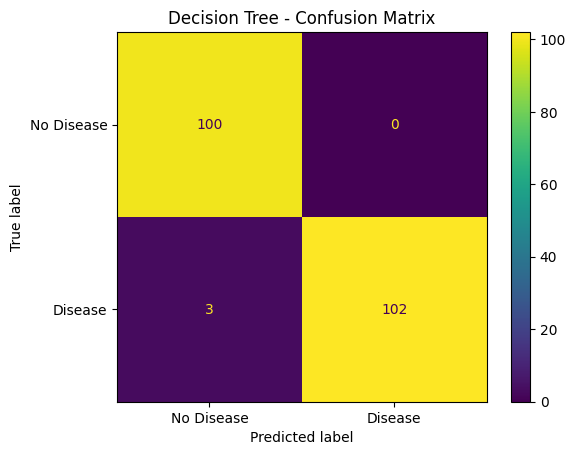

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_model.predict(x_test),
    display_labels=["No Disease", "Disease"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

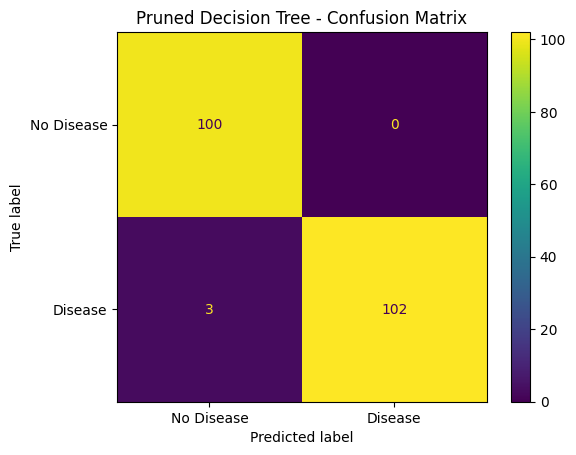

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pruned_tree.predict(x_test),
    display_labels=["No Disease", "Disease"]
)

plt.title("Pruned Decision Tree - Confusion Matrix")
plt.show()

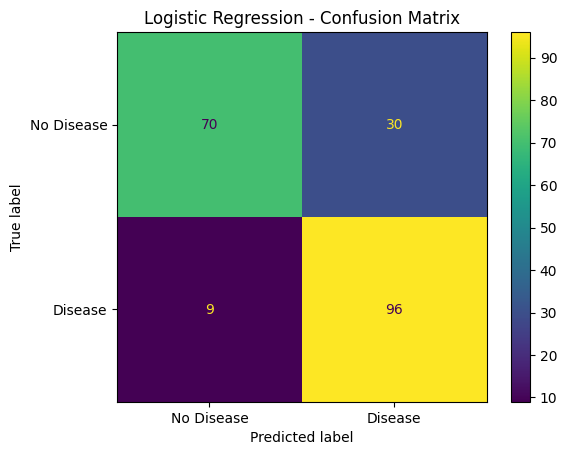

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_test_pred,
    display_labels=["No Disease", "Disease"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()